# Report 1: Analysis of energy and device usage throughout the day

This report aims to use the provided data on electricity and gas usage, as well as the data on the devices that were installed in the house to provide an overview of the consumption of gas and electricity throughout the day, as well as to analyse how device usage differs between day and night.


We can start by importing the home messages file and creating the "myhome" database. Then we can insert the files into the database and return the data from the database as a pandas dataframe.

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
import random
from scipy import stats
pd.options.mode.copy_on_write = True

In [2]:
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [20]:
files = check_filepaths("smartthings.*","smartthings")
for file in files:
    db.insert_table_smartthings(file)

In [21]:
files = check_filepaths("P1g-*","P1g")
for file in files:
    db.insert_table_P1g(file)

/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2023-11-01-2023-12-24.csv.gz was already appended to table 'P1g'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2023-01-01-2023-02-10.csv.gz was already appended to table 'P1g'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2022-11-01-2022-12-29.csv.gz was already appended to table 'P1g'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2025-1-01-2025-2-10.csv was already appended to table 'P1g'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2022-12-01-2023-01-10.csv.gz was already appended to table 'P1g'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2024-7-01-2024-8-14.csv was already appended to table 'P1g'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1g/P1g-2023-12-01-2024-1-13.csv.gz was already appended to table 'P

In [22]:
files = check_filepaths("P1e-*","P1e")
for file in files:
    db.insert_table_P1e(file)

/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2023-03-01-2023-04-04.csv.gz was already appended to table 'P1e'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2024-6-01-2024-7-02.csv was already appended to table 'P1e'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2023-11-01-2023-11-28.csv.gz was already appended to table 'P1e'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2024-9-01-2024-10-16.csv was already appended to table 'P1e'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2024-4-01-2024-4-21.csv.gz was already appended to table 'P1e'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2022-01-01-2022-09-22.csv.gz was already appended to table 'P1e'
/Users/elena/Documents/Sem_2/Essentials for Data Science/GA2025_07/data/P1e/P1e-2024-2-01-2024-3-03.csv.gz was already appended to table 'P1e

KeyboardInterrupt: 

And now fetch them and insert them into a pandas dataframe

In [3]:
Energy_usage = db.return_whole_table("P1e")
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2
0,1647612900,6506.377,5313.255,0.0,0.0
1,1647613800,6506.377,5313.516,0.0,0.0
2,1647614700,6506.377,5314.241,0.0,0.0
3,1647615600,6506.377,5314.800,0.0,0.0
4,1647616500,6506.377,5314.933,0.0,0.0


### Question 1: Does average electricity use change throughout the day?

The First kind of analysis is about the energy usage throughout the day, which means we first need to convert the epochs (so unix time) into datetime and extract the times seperately from the whole date.

In [4]:
Energy_usage["date"] = pd.to_datetime(Energy_usage.loc[:,"epoch"]*10**9).dt.date
Energy_usage["time"] = pd.to_datetime(Energy_usage.loc[:,"epoch"]*10**9).dt.strftime("%H:%M")
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,14:15
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,14:30
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,14:45
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,15:00
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,15:15


Since the energy usage columns indicate the overall energy usage for low and high cost hours we need to create a new column that checks the usage at each timepoint to the previous timepoint for both columns and then takes the sum of those two values as the consumption for that period.

In [5]:
Energy_usage["usage"] = Energy_usage.loc[:,"Electricity_imported_T1"].diff() + Energy_usage.loc[:,"Electricity_imported_T2"].diff()
Energy_usage.head()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,time,usage
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18,14:15,NaN
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18,14:30,0.261
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18,14:45,0.725
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18,15:00,0.559
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18,15:15,0.133


Now we can use a lineplot to see how energy consumption varies roughly throughout the day. The red lines mark a shift from high-cost to low-cost hours / vice versa

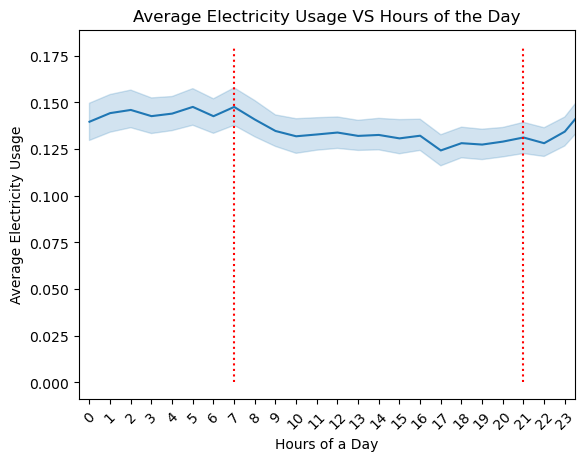

In [6]:
ax = sns.lineplot(Energy_usage, x = "time", y = "usage", estimator= "mean")
plt.xticks(np.arange(0,24, step = 1), rotation = 45, labels = range(0,24,1))
plt.xlim(-0.5, 23.5)
plt.vlines(x = [7,21], ymin = 0, ymax= 0.18, linestyles= "dotted", color = "red")
ax.set(xlabel = "Hours of a Day", ylabel = "Average Electricity Usage", title = "Average Electricity Usage VS Hours of the Day")
plt.show()

Looking at the plot, there is not a huge difference between the different hours of the day. It does look like more energy is used during the low-cost hours than the high-cost ones, which intuitively does make sense, as this saves money.

### Question 2: Is it possible to identify intervals of time when nobody is home? 


There are multiple ways of approaching this question. First of all, we might hypothesise that during intervals where nobody is home, electricity consumption might be significantly lower than when people are at home. Secondly, gas usage might also be significantly lower when nobody is home -- especially during the coldest days of winter. Third, since smartthings contains data from motion-activated sensors and other devices which need to be used actively in order to be active, if there are large intervals of time when these devices are not used, we can assume that nobody was home to use them. 

#### 2.a: Can we see intervals of time when electricity consumption dips when looking at single dates?

In order to investigate this question, we can take a look at data from a random selection of days throughout the period for which we have data. As such, we draw a random sample of 20 days. Since we cannot be certain that this household does not use some electric devices for heating (such as space-heaters, or electric floor-heating in parts of the house), and since for later questions we will be investigating gas use to answer the bigger question, we use a random sample of dates from only cold months.

In [7]:
max(Energy_usage["date"])

cold_months_24 = Energy_usage[((Energy_usage["date"] >= datetime.date(2024,10,1)) | (Energy_usage["date"] <= datetime.date(2024,3,1))) & (Energy_usage["date"] < datetime.date(2025,1,1)) & (Energy_usage["date"] > datetime.date(2023,12,31))]
cold_months_23 = Energy_usage[((Energy_usage["date"] >= datetime.date(2023,10,1)) | (Energy_usage["date"] <= datetime.date(2023,3,1))) & (Energy_usage["date"] < datetime.date(2024,1,1)) & (Energy_usage["date"] > datetime.date(2022,12,31))]
cold_months_22 = Energy_usage[((Energy_usage["date"] >= datetime.date(2022,10,1)) | (Energy_usage["date"] <= datetime.date(2022,3,1))) & (Energy_usage["date"] < datetime.date(2023,1,1)) & (Energy_usage["date"] > datetime.date(2021,12,31))]


cold_months = pd.concat([cold_months_24, cold_months_23], ignore_index= True)
cold_months = pd.concat([cold_months, cold_months_22], ignore_index=True)

In [ ]:
random.seed(203903)
random_days = random.sample(list(cold_months["date"]), k = 10)    

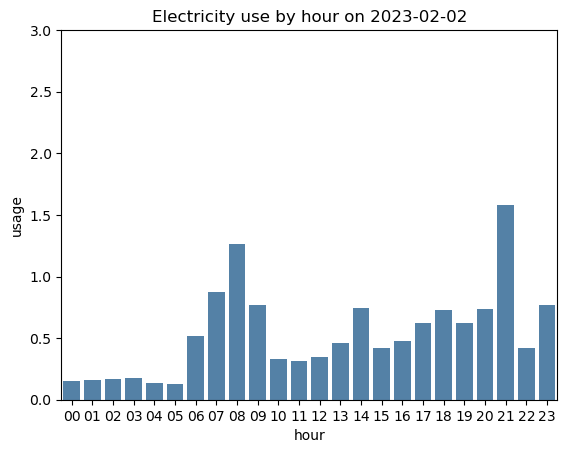

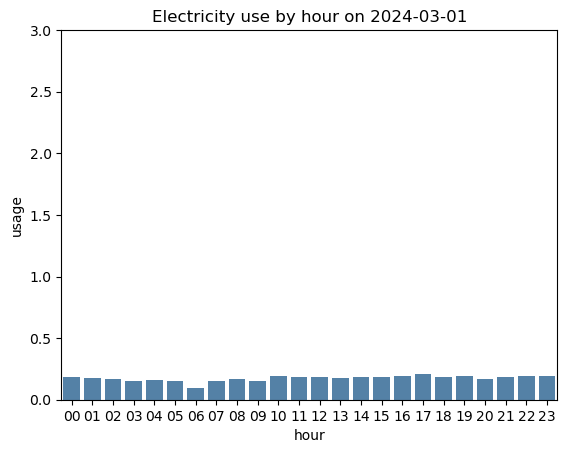

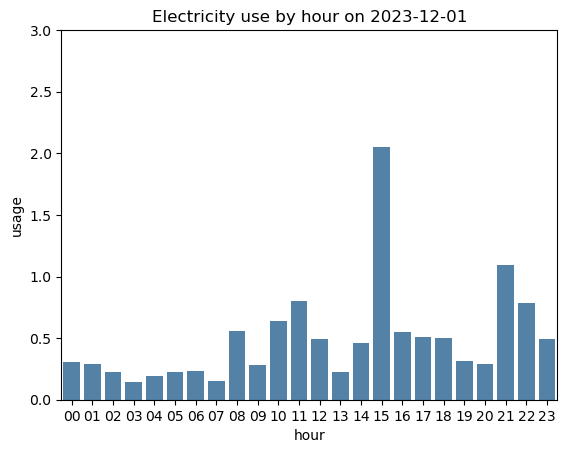

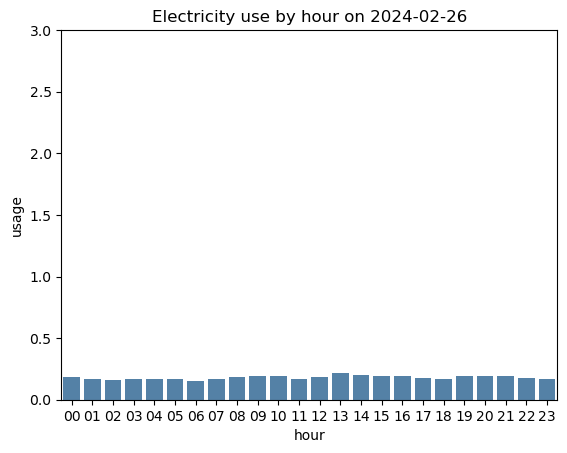

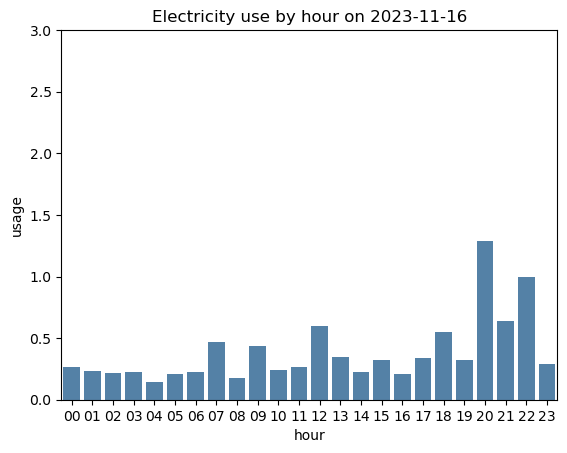

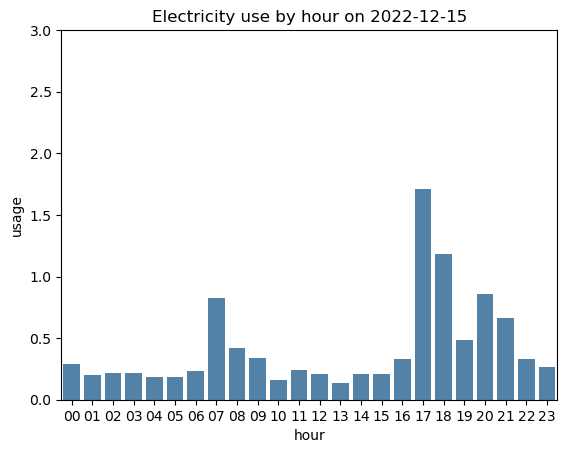

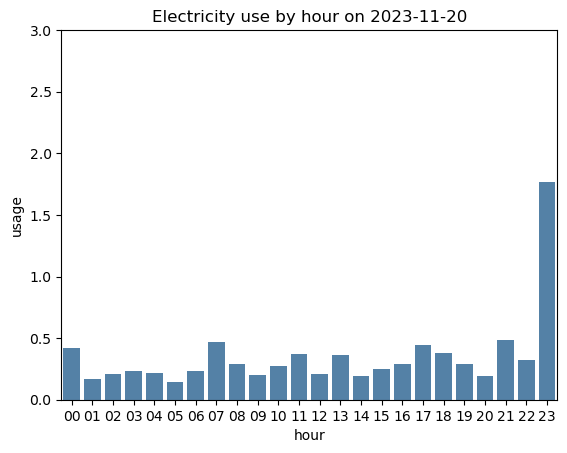

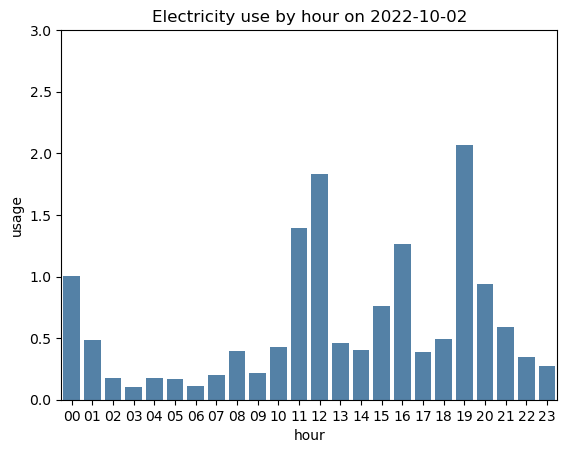

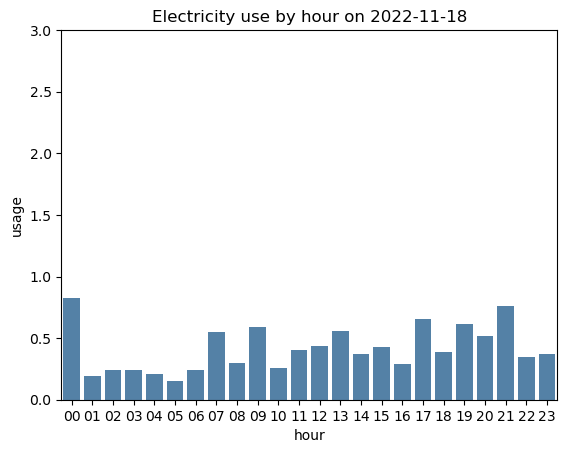

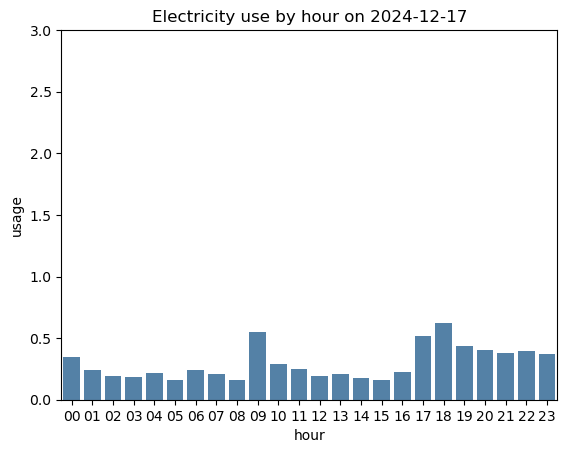

In [17]:
Energy_usage[["hour", "minute"]] = Energy_usage.loc[:,"time"].str.split(":", n = 1, expand=True)

cold_days = Energy_usage[Energy_usage["date"].isin(random_days)]

cold_days = cold_days[["date", "usage", "hour"]].groupby(["date", "hour"]).sum()

def create_day_barplot(df, date, color, energy):
    temp_df = df.loc[date]
    fig, ax = plt.subplots()
    ax.set_ylim(0,3)
    plt.title(f"{energy} use by hour on {date}")
    sns.barplot(temp_df, x = "hour", y = "usage", ax = ax, color = color)


for date in random_days:
    create_day_barplot(cold_days, date, "steelblue", "Electricity")
    

    


#### 2.b: What is the average passive electricity use of the house?

When it comes to household electricity use, it is also common for devices (such as a fridge or ventilation system) to passively consume electricity. As such, energy usage for no time is likely to be zero. In order to assess what is likely to be the average passive electricity use, we can take the mean electricity use at a time when everyone in the household is likely to be asleep. As we can see in the barplot below, the average electricity use for times between 02:00 and 05:00 is much lower than the average electricity use during other times of the day, through the whole period.

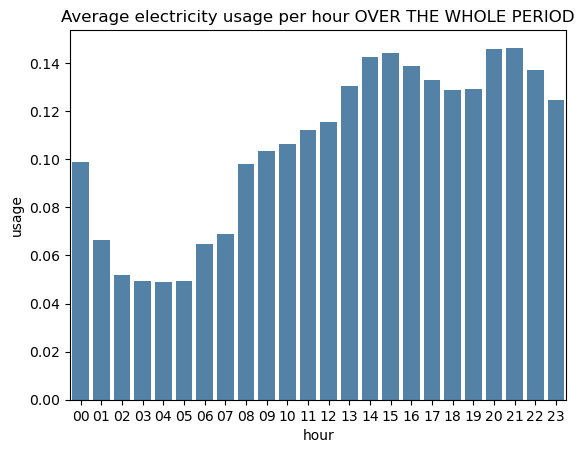

In [14]:
average_electric_by_hour = Energy_usage[["usage", "hour"]].groupby(["hour"]).mean()
plt.figure()
sns.barplot(average_electric_by_hour, x = "hour", y = "usage", color = "steelblue")
title = plt.title("Average electricity usage per hour OVER THE WHOLE PERIOD")


#### 2.c: Do the peaks in electricity use seen in the above graphs differ significantly from the passive electricity use estimates? (Hypothesis-testing using paired-samples t-test)

Thus, we can take electricity usage during times 01:00 to 05:00 and treat it as a "reference value" for the passive electricity use for this house. Then, we can perform hypothesis-testing via a paired-sample t-test to check whether certain intervals of time have electricity usage which is significantly different than the passive consumption time intervals.

First, we can check the first date plotted above, 20th January 2023. 

There seems to be clear peaks of use around 09:00, 18:00 and 21:00, indicating that someone must have been home during those times. Is the electricity usage significantly different between 18:00 and 22:00 and between 01:00 and 05:00? For reference, we re-plot the barplot for this date below.

Then, is electricity usage significantly different between 10:00 and 14:00, when the lowest valley of electricity use that day appears to have happened?

In order to maximise the number of samples for the t-test, we use the electricity usage values in 15-minute-intervals instead of the 'binned' values by hour used in the barplots above.

In [17]:
jan_20 = Energy_usage[Energy_usage["date"] == random_days[0]]
jan_20[["date", "time", "usage", "hour"]]


def is_significant(test_use, reference_use):
    t_test = stats.ttest_rel(test_use["usage"], reference_use["usage"], alternative= "greater")
    p_value = t_test[1]
    if p_value > 0.05:
        return(" not ", p_value)
    else:
        return(" ", p_value)

def between_hour_t_test(day_df, peak_hours, possibly_absent_hours, reference_hours, energy):
    passive_use = day_df[day_df["hour"].isin(reference_hours)]
    peak_use = day_df[day_df["hour"].isin(peak_hours)]
    possibly_absent_use = day_df[day_df["hour"].isin(possibly_absent_hours)]
    significance_peak, p_val_peak = is_significant(peak_use, passive_use)
    print(f"{energy} use from {peak_hours[0]}:00 to {peak_hours[-1]}:00 is{significance_peak}significantly greater than passive {energy.lower()} use. p-value = {p_val_peak}")
    significance_absent, p_val_absent = is_significant(possibly_absent_use, passive_use)
    print(f"{energy} use from {possibly_absent_hours[0]}:00 to {possibly_absent_hours[-1]}:00 is{significance_absent}significantly greater than passive {energy.lower()} use. p-value = {p_val_absent}")
    #significance_actives, p_val_actives = is_significant(possibly_absent_use, peak_use)
    #print(f"Electricity use from {possibly_absent_hours[0]}:00 to {possibly_absent_hours[-1]}:00 is{significance_actives}significantly different than electricity use between {peak_hours[0]} and {peak_hours[1]}. p-value = {p_val_actives}")



create_day_barplot(cold_days, datetime.date(2023,1,20), "steelblue", "Electricity")   
between_hour_t_test(jan_20, peak_hours=["18", "19", "20", "21", "22"], possibly_absent_hours=["10", "11", "12", "13", "14"], reference_hours=["01", "02", "03", "04", "05"], energy = "Electricity")


KeyError: datetime.date(2023, 1, 20)

The one-sided paired samples t-test above indicates that electricity use overnight (what we can consider the passive electricity use of the electrical devices in the house) is significantly lower than the use in both of the "peak" hours and in the "valley" hours, showing that it is unlikely that nobody was actively using electrical devices between those hours.

Another interesting date to consider is 12th October 2023 (2023-10-12). It appears that between the hours of 9:00 and 12:00, electricity use is relatively low, showing that perhaps during this time interval, nobody was home. On the other hand, clearly someone was home from 17:00 to 20:00. We can check if the electricity usage patterns between these two time intervals are significantly different from the overnight passive usage.

Indeed, the one-tailed t-test shows that electricity usage between 09:00 and 12:00 is not significantly greater than elecrticity usage overnight. As such, we cannot rule out the possibility that nobody was actively using electrical devices during that time-interval. 

Electricity use from 17:00 to 20:00 is significantly greater than passive electricity use. p-value = 0.007322171330255397
Electricity use from 09:00 to 12:00 is not significantly greater than passive electricity use. p-value = 0.11056470534469814


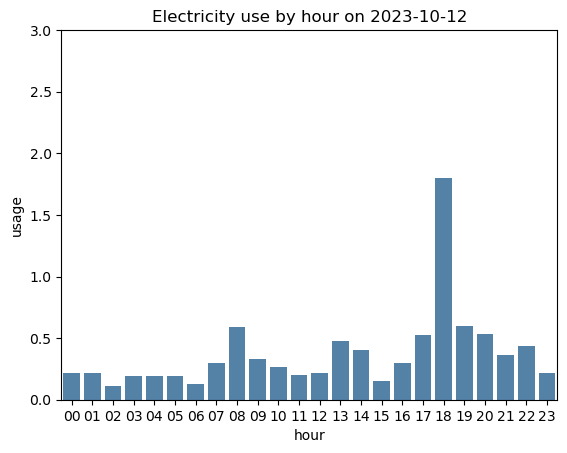

In [ ]:
create_day_barplot(cold_days, datetime.date(2023,10,12), "steelblue", "Electricity")
oct_12 = Energy_usage[Energy_usage["date"] == datetime.date(2023,10,12)]
oct_12[["date", "time", "usage", "hour"]]
between_hour_t_test(oct_12, peak_hours=["17", "18", "19", "20"], possibly_absent_hours=["09", "10", "11", "12"], reference_hours=["02", "03", "04", "05"], energy = "Electricity")

Lastly, there are days where it is fairly clear that nobody was home for the whole day, judging by the fact that the electricity use does not change throughout the day. One of these days is 1st January 2023 -- not a surprising finding as this is New Year's Day. As we can see from the barplot below, electricity usage remains constant throughout the day. 

The t-tests also corroborate that there is no significant difference in electricity usage between the early morning hours of 02:00 - 05:00 and the late morning hours of 09:00 - 12:00, and there is also no significant difference in electricity usage between 02:00 - 05:00 and the late afternoon hours of 17:00 - 20:00. As such, we cannot rule out that nobody was using electrical devices actively throughout the day.

Electricity use from 17:00 to 20:00 is not significantly greater than passive electricity use. p-value = 0.7710915086707656
Electricity use from 09:00 to 12:00 is not significantly greater than passive electricity use. p-value = 0.7719899762107677


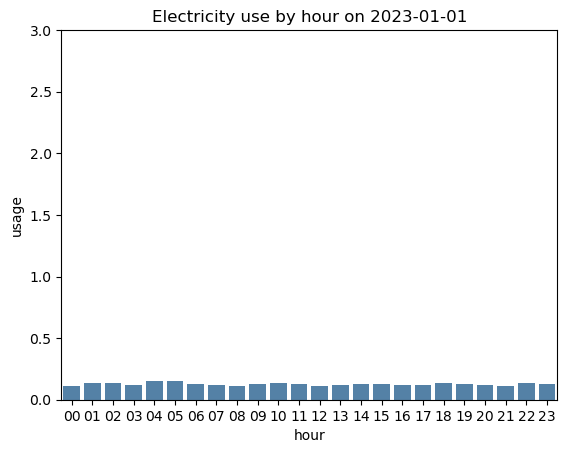

In [ ]:
create_day_barplot(cold_days, datetime.date(2023,1,1), "steelblue", "Electricity")
jan_1 = Energy_usage[Energy_usage["date"] == datetime.date(2023,1,1)]
jan_1[["date", "time", "usage", "hour"]]
between_hour_t_test(jan_1, peak_hours=["17", "18", "19", "20"], possibly_absent_hours=["09", "10", "11", "12"], reference_hours=["02", "03", "04", "05"], energy = "Electricity")

#### 2.e: Can we see intervals of time when gas consumption dips when looking at single dates?


As with the previous question, the barplots below show that it is easy to spot intervals of time when gas usage increases or decreases. To see whether these intervals can help spot whether someone is home or not, we can check the same three dates as we investigated for electricity, and see whether the energy use patterns in gas are similar to those of electricity, and whether overnight usage is significantly different than certain intervals of the day. 

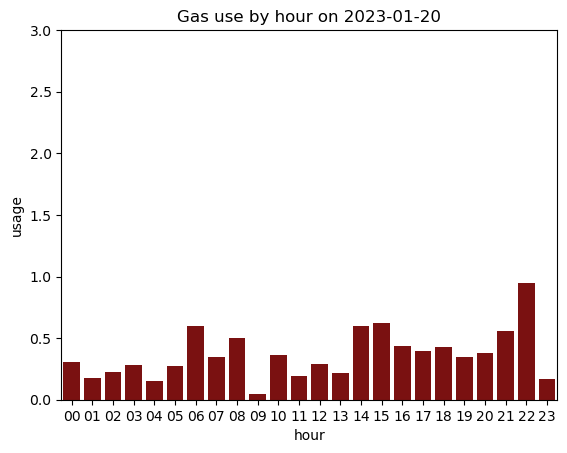

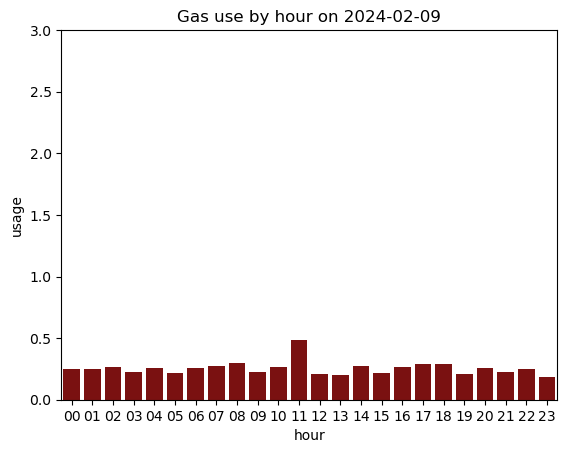

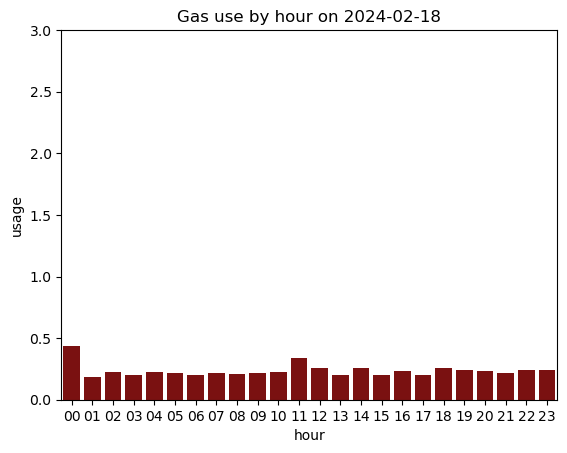

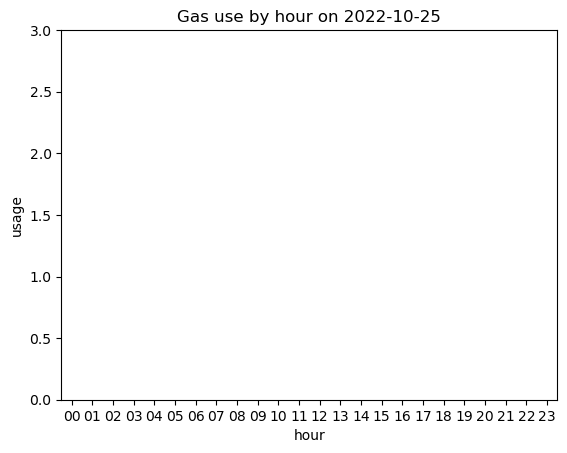

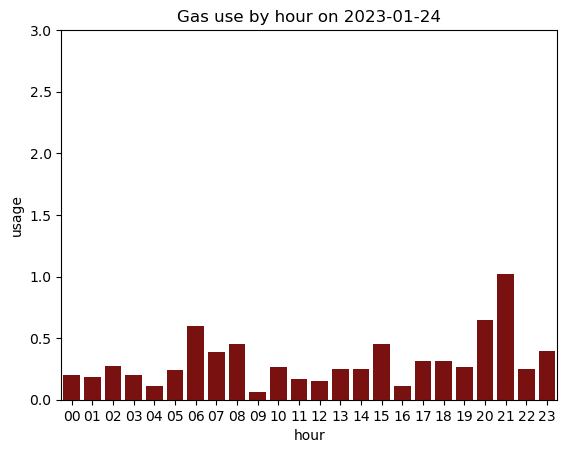

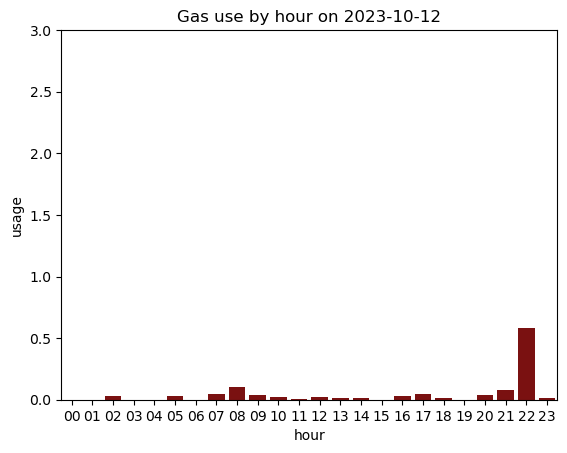

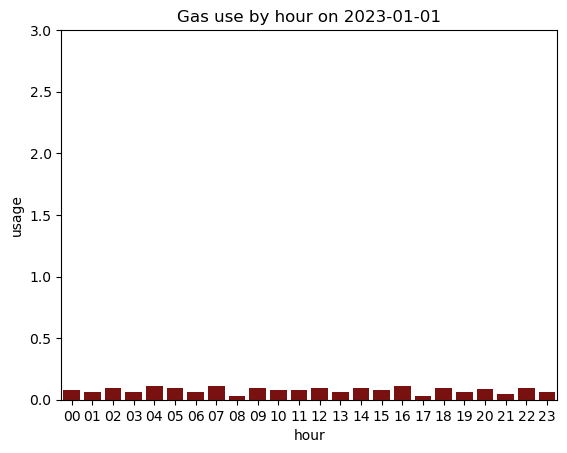

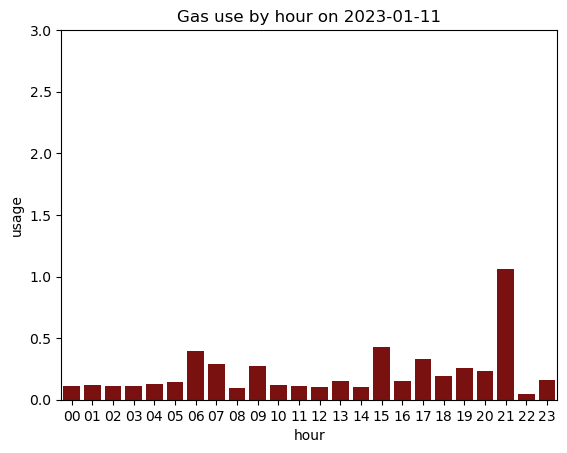

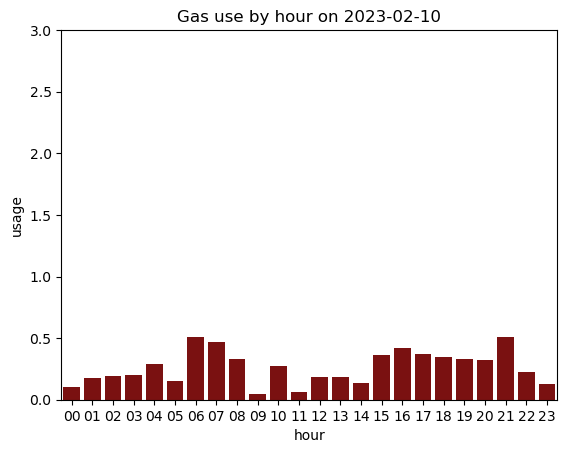

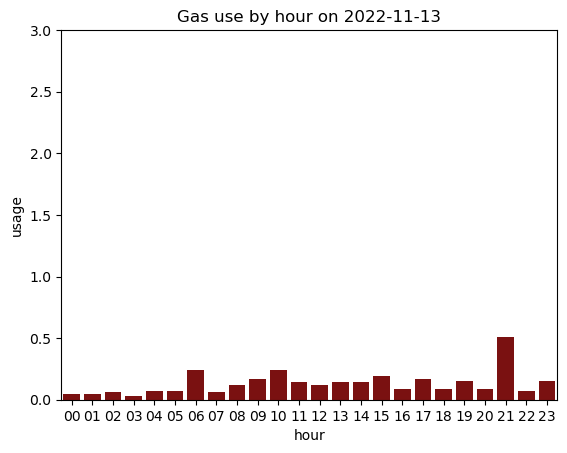

In [ ]:
gas_usage = db.return_whole_table("P1g")
gas_usage["date"] = pd.to_datetime(gas_usage.loc[:,"epoch"]*10**9).dt.date
gas_usage["time"] = pd.to_datetime(gas_usage.loc[:,"epoch"]*10**9).dt.strftime("%H:%M")

gas_usage["usage"] = gas_usage.loc[:,"Total_gas_used"].diff()


gas_usage[["hour", "minute"]] = gas_usage.loc[:,"time"].str.split(":", n = 1, expand=True)

cold_days_gas = gas_usage[gas_usage["date"].isin(random_days)]
cold_days_gas = cold_days_gas[["date", "usage", "hour"]].groupby(["date", "hour"]).sum()

for date in random_days:
    create_day_barplot(cold_days_gas, date, "darkred", "Gas")

#### 2.f: What is the average passive gas use of the house?

As with electricity, we can imagine that the house may use gas "passively" to keep the temperature steady overnight during the winter. This same passive use is expected also when the occupants are not home, as the temperature would still need to be kept steady. However, when occupants are awake and at home, we might imagine that they adjust the temperature to their comfort. We calculate the passive gas consumption of the house below.

Just as before, we see that the lowest gas usage occurs between 01:00 - 05:00, when the occupants are most likely asleep.

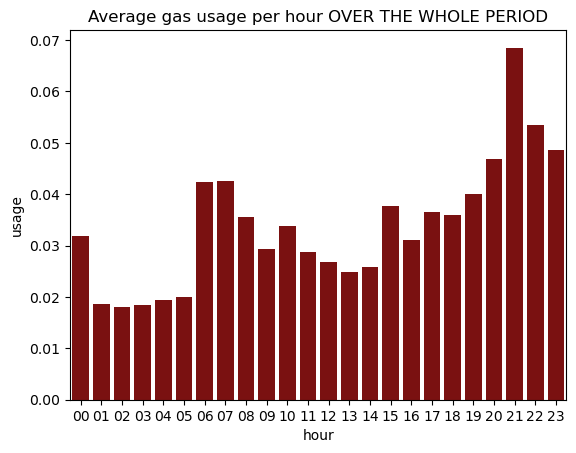

In [ ]:
average_gas_by_hour = gas_usage[["usage", "hour"]].groupby(["hour"]).mean()
plt.figure()
sns.barplot(average_gas_by_hour, x = "hour", y = "usage", color = "darkred")
title = plt.title("Average gas usage per hour OVER THE WHOLE PERIOD")

#### 2.g: Do the peaks in gas use seen in the above graphs differ significantly from the passive gas use estimates? (Hypothesis-testing using paired-samples t-test)

We check the same dates as we examined for electricity use to see if we can observe similar patterns for the same time intervals and come to a more conclusive result regarding whether those are time-intervals when nobody was home.

First, we check 23rd January 2023. 

For electricity 09:00, 18:00 and 21:00, indicating that someone must have been home during those times. Is the electricity usage significantly different between 18:00 and 22:00 and between 01:00 and 05:00? For reference, we re-plot the barplot for this date below.

Then, is electricity usage significantly different between 10:00 and 14:00, when the lowest valley of electricity use during the daytime appears to have happened?


Gas use from 18:00 to 22:00 is significantly greater than passive gas use. p-value = 0.0012476733113834552
Gas use from 10:00 to 14:00 is not significantly greater than passive gas use. p-value = 0.09357032096878247


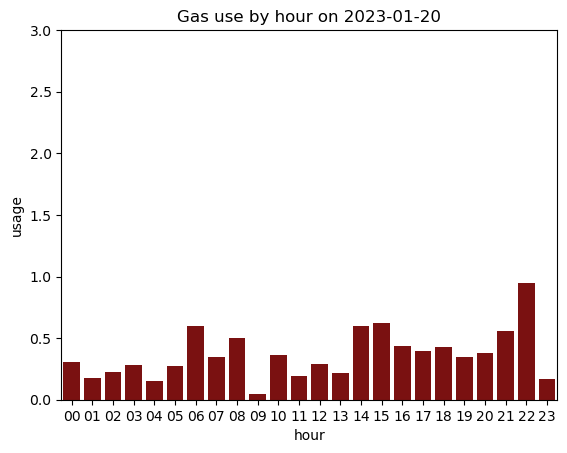

In [ ]:
jan_20_gas = gas_usage[gas_usage["date"] == datetime.date(2023,1,20)]
jan_20_gas[["date", "time", "usage", "hour"]]
create_day_barplot(cold_days_gas, datetime.date(2023,1,20), "darkred", "Gas")   
between_hour_t_test(jan_20_gas, peak_hours=["18", "19", "20", "21", "22"], possibly_absent_hours=["10", "11", "12", "13", "14"], reference_hours=["01", "02", "03", "04", "05"], energy = "Gas")


Whereas on 20th January electricity use between 10:00 to 14:00 was significantly greater than passive electricity use, this is not the case for gas usage. This could either indicate either that nobody was home but electrical devices were left on (for example the washing machine), or that somebody was home but that the temperature was warm enough to not require extra heating.

For 12th October, whereas electricity usage was significantly greater than passive electricity use during the hours with highest use, but not significantly greater during the hours of possible absence, gas usage on 25th October was not significantly greater during either of these timespans. Since this date is rather early in the cold months, the difference could be attributed to that fact.

Gas use from 19:00 to 22:00 is not significantly greater than passive gas use. p-value = 0.0631793101411307
Gas use from 09:00 to 12:00 is not significantly greater than passive gas use. p-value = 0.20215759672329497


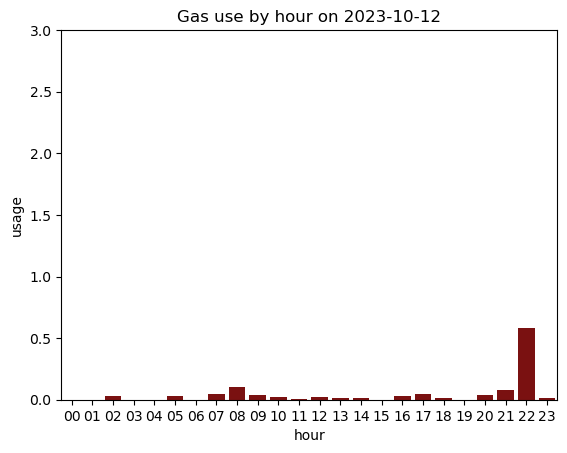

In [ ]:
create_day_barplot(cold_days_gas, datetime.date(2023,10,12), "darkred", "Gas")
oct_12_gas = gas_usage[gas_usage["date"] == datetime.date(2023,10,12)]
oct_12_gas[["date", "time", "usage", "hour"]]
between_hour_t_test(oct_12_gas, peak_hours=["19", "20", "21", "22"], possibly_absent_hours=["09", "10", "11", "12"], reference_hours=["02", "03", "04", "05"], energy = "Gas")

For New Year's day 2023, we hypothesised that according to the electricity usage patterns, the family might have been out all day. The gas usage patterns seem to also corroborate this hypothesis.

Gas use from 17:00 to 20:00 is not significantly greater than passive gas use. p-value = 0.8443326563269182
Gas use from 09:00 to 12:00 is not significantly greater than passive gas use. p-value = 0.6145538654800529


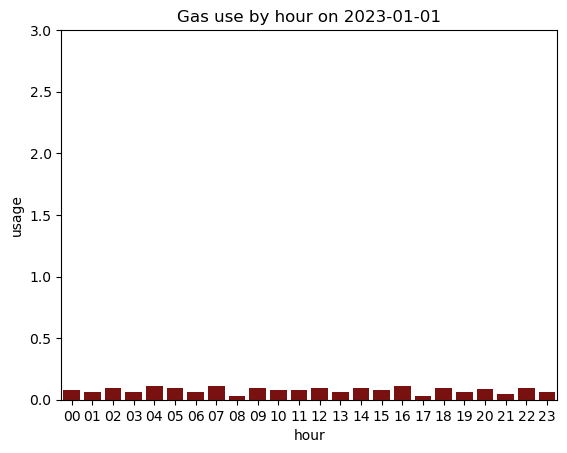

In [ ]:
create_day_barplot(cold_days_gas, datetime.date(2023,1,1), "darkred", "Gas")
jan_1_gas = gas_usage[gas_usage["date"] == datetime.date(2023,1,1)]
jan_1_gas[["date", "time", "usage", "hour"]]
between_hour_t_test(jan_1_gas, peak_hours=["17", "18", "19", "20"], possibly_absent_hours=["09", "10", "11", "12"], reference_hours=["02", "03", "04", "05"], energy = "Gas")

#### 2.h: Is there any activity registered on smart devices overnight?

In [ ]:
smartthings_jan20 = db.return_entries_between_dates("smartthings", time_inp = "2023-01-20", dataframe = True)
smartthings_jan20

1674169200 1674255540


,id,name,epoch,capability,attribute,unit,value_int,value_str
0,1427990,Shed (sensor),1674169256,temperatureMeasurement,temperature,°C,1.7,None
1,1427991,Living room (button),1674169302,temperatureMeasurement,temperature,°C,17.5,None
2,1427992,Green Room (move cube),1674169349,motionSensor,motion,None,NaN,active
3,1427993,Green Room (move cube),1674169351,winterdictionary35590.cube,action,None,NaN,slide
4,1427994,Green Room (move cube),1674169351,winterdictionary35590.cube,action,None,NaN,Ready
...,...,...,...,...,...,...,...,...
2919,2476647,Garden air (sensor),1674255098,relativeHumidityMeasurement,humidity,%,89.0,None
2920,2476648,Bathroom (sensor shelf),1674255112,temperatureMeasurement,temperature,°C,18.2,None
2921,2476649,Attic (sensor),1674255392,temperatureMeasurement,temperature,°C,18.1,None
2922,2476650,Shed (sensor),1674255439,temperatureMeasurement,temperature,°C,0.1,None


In [16]:
smartthings_jan20["date"] = smartthings_jan20["epoch"].apply(timestamp_into_gmt2)
#smartthings_jan20["time"] = pd.to_datetime(smartthings_jan20.loc[:,"epoch"]*10**9).dt.strftime("%H:%M")


NameError: name 'smartthings_jan20' is not defined